# Diferencijalna jednačina - Masa-opruga-prigušivač sistem

Numeričko rešavanje diferencijalne jednačine drugog reda za sistem sa prinudnim oscilacijama.

Uvoz neophodnih paketa

In [28]:
import numpy as np                  # Paket za numeričku matematiku
from scipy.integrate import odeint  # Paket za rešavanje diferencijalnih jednačina
import matplotlib.pyplot as plt     # Paket za iscrtavanje grafika   

## Konstante sistema:

In [ ]:
M = 3.2e-2  # kg - masa
c = 3e5     # N/m - konstanta opruge
A = 5e-5    # m^2 - površina
P = 40e5    # N/m^2 - pritisak
u = 1       # koeficijent prigušenja

## Opis jednačine:

Diferencijalna jednačina sistema:
\begin{align}
M x'' + \mu x' + c x & = F = A P \sin(2 \pi t) \\
\end{align}

Transformacija u sistem prvog reda za numeričko rešavanje:
\begin{align}
x'(t) & = v(t) \\
v'(t) & = (F - \mu v(t) - c x) / M \\
\end{align}

In [ ]:
def jednacina(y, t):
    """Sistem diferencijalnih jednačina prvog reda"""
    x, v = y
    dydt = [v, (A * P * np.sin(2 * np.pi * t) - u*v - c*x) / M]
    return dydt

## Parametri simulacije:

In [31]:
# Početne vrednosti za put i brzinu (prvi izvod)
y0 = [0,  0]

# Vremenski interval i korak
T_pocetak = 0
T_kraj = 3
f_odabiranja = 10000

T_odabiranja = 1/f_odabiranja
t = np.arange(T_pocetak, T_kraj, T_odabiranja)

## Rešavanje jednačine

In [32]:
# Vraća dva niza vrednosti, za x i prvi izvod
rezultat = odeint(jednacina, y0, t)

## Iscrtavanje odziva

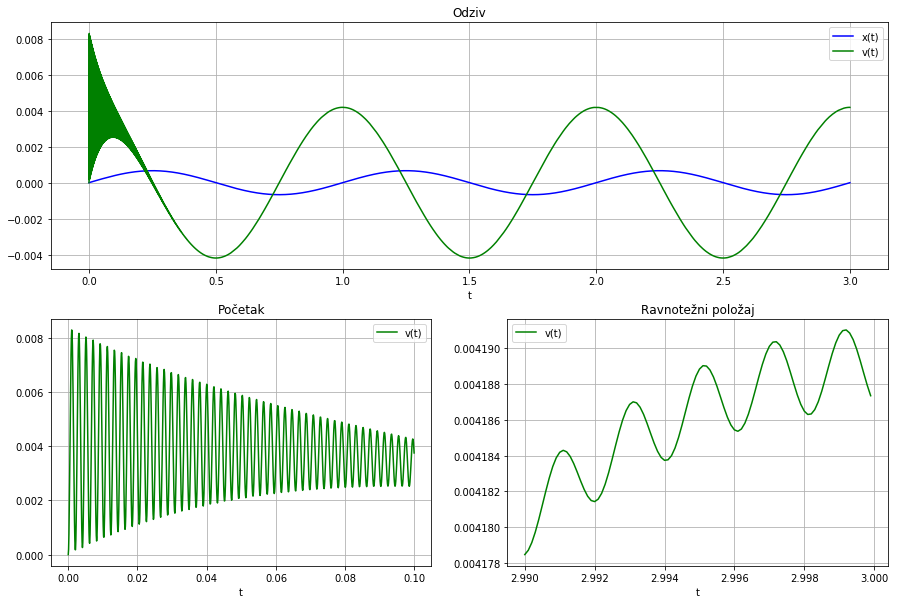

In [33]:
# Iscrtavanje grafika
plt.figure(figsize=(15,10))

plt.subplot(211)
plt.plot(t, rezultat[:, 0], 'b', label='x(t)')
plt.plot(t, rezultat[:, 1], 'g', label='v(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.title('Odziv')

# Iscrtavanje početka
plt.subplot(223)
t2 = t[t < 0.1] # koristi samo početne vremenske odbirke 
plt.plot(t2, rezultat[:len(t2), 1], 'g', label='v(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.title('Početak')

# Iscrtavanje ravnotežnog položaja
plt.subplot(224)
t3 = t[t > t[-1] - 0.01] # koristi samo krajnje vremenske odbirke, tj. samo one blizu poslednjeg vremenskog odbirka - t[-1]
plt.plot(t3, rezultat[-len(t3):, 1], 'g', label='v(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.title('Ravnotežni položaj')

plt.show()

### Zaključci:
- Primećuju se oscilacije u brzini na početku (prolazni režim)
- Tokom vremena vibracije slabe, ali nikad ne prestaju (ustaljeni režim)

Dalje se računa amplituda ove oscilacije u ravnotežnom položaju:

-------------------

## Spektar snage brzine

In [ ]:
# Računanje FFT spektra za poslednjih jednu sekundu (ustaljeni režim)
spektar = np.fft.fft(rezultat[-f_odabiranja:,1]) * T_odabiranja
freq = np.fft.fftfreq(f_odabiranja, d=T_odabiranja)

# Uzimanje samo pozitivnih frekvencija
mask = freq >= 0
freq = freq[mask]
spektar_snage = spektar.real[mask]**2 * 2

# Iscrtavanje spektra
plt.figure(figsize=(15,10))
plt.semilogy(freq, spektar_snage, linewidth=4)
plt.xlabel('f [Hz]')
plt.ylabel('Spektar snage')
plt.title('Frekvencijski spektar snage brzine')
plt.grid()
plt.show()

### Izračunavanje frekvencija i amplituda sinusoida u brzini

In [ ]:
# Pronalaženje dominantnih frekvencija u spektru
sort = np.argsort(spektar_snage)[::-1]
maksimumi = [sort[0]]

# Pronalazak drugog maksimuma koji je dovoljno udaljen od prvog
for i in range(1, len(sort)):
    if np.abs(maksimumi[0] - sort[i]) > 10:
        maksimumi.append(sort[i])
        break

# Ispis rezultata
for i in range(len(maksimumi)):
    print(f'Frekvencija{i+1}={freq[maksimumi[i]]:.2f} Hz, Amplituda{i+1}={np.sqrt(spektar_snage[maksimumi[i]]*2):.6e}')